# Sentiment Analysis on IMDb Movie Reviews Using Natural Language Processing (NLP)

## CodTech Data Analysis Internship - Task 4

### Project Overview

Sentiment Analysis is a Natural Language Processing (NLP) technique used to determine whether a piece of text expresses a positive, negative, or neutral sentiment. It is widely used in customer feedback analysis, social media monitoring, product review analysis, and market research.

In this project, sentiment analysis is performed on the IMDb Movie Reviews Dataset. The reviews are preprocessed using NLP techniques such as text cleaning and stopword removal. The processed text is then transformed into numerical features using TF-IDF Vectorization and classified using a Logistic Regression model.

### Objective

The primary objective of this project is to analyze movie reviews and classify them into positive and negative sentiments using Natural Language Processing and Machine Learning techniques.

### Tools and Technologies Used

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn
- NLTK
- Scikit-Learn

In [2]:
# Import Libraries
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import nltk
from nltk.corpus import stopwords

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load Datasets
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:
# Data Exploration
df = pd.read_csv('IMDB Dataset.csv.zip')

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
## Data Preprocessing
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

Dataset Shape: (50000, 2)

Columns:
Index(['review', 'sentiment'], dtype='object')

Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [7]:
df.isnull().sum()

,0
review,0
sentiment,0


In [8]:
# Text Cleaning and Stopword Removal
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [9]:

df['clean_review'] = df['review'].apply(clean_text)

df[['review', 'clean_review']].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...


In [10]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):

    words = text.split()

    filtered_words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(filtered_words)

In [11]:
df['clean_review'] = df['clean_review'].apply(remove_stopwords)

df[['clean_review']].head()

,clean_review
0,one reviewers mentioned watching oz episode ho...
1,wonderful little production filming technique ...
2,thought wonderful way spend time hot summer we...
3,basically family little boy jake thinks zombie...
4,petter mattei love time money visually stunnin...


In [12]:
# Sentiment Label Encoding
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

df['sentiment'].value_counts()

,count
sentiment,
1,25000
0,25000


In [13]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(
    df['clean_review']
)

y = df['sentiment']

In [14]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (40000, 5000)
Testing Data: (10000, 5000)


In [16]:
# Model Training
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [17]:
y_pred = model.predict(X_test)

In [18]:
# Model Evaluation
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 89.22 %


In [19]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.88      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



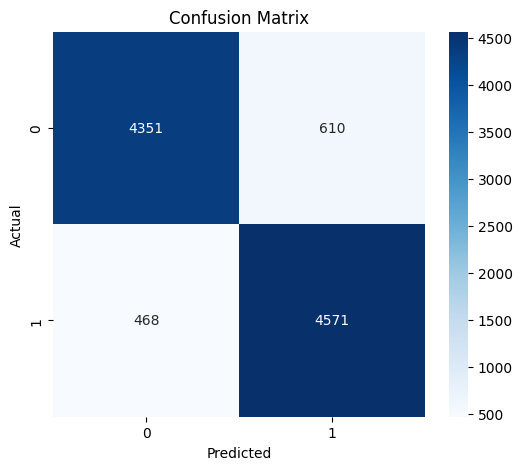

In [20]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

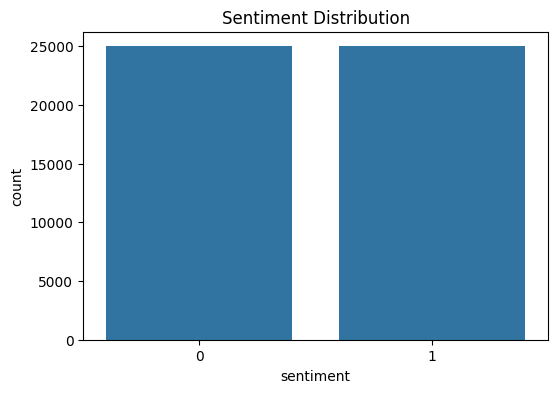

In [21]:
# Data Visualization
plt.figure(figsize=(6,4))

sns.countplot(
    x=df['sentiment']
)

plt.title("Sentiment Distribution")
plt.show()

## Model Performance

The Logistic Regression model was trained on 40,000 movie reviews and evaluated on 10,000 reviews.

The model achieved a high accuracy score and demonstrated effective sentiment classification using TF-IDF vectorization and NLP preprocessing techniques.

## Business Insights

1. The dataset contained 50,000 movie reviews with equal distribution of positive and negative sentiments.

2. No missing values were found in the dataset.

3. Text preprocessing techniques such as lowercase conversion, removal of special characters, and stopword removal significantly improved data quality.

4. TF-IDF Vectorization was used to convert textual reviews into numerical features suitable for machine learning.

5. Logistic Regression achieved an accuracy of 89.22%, demonstrating strong performance in sentiment classification.

6. The model successfully distinguished between positive and negative reviews with high precision and recall.

7. This approach can be applied to customer reviews, social media comments, and product feedback analysis for business decision-making.

## Conclusion

This project successfully performed sentiment analysis on IMDb movie reviews using Natural Language Processing techniques.

The dataset was preprocessed through text cleaning and stopword removal, followed by TF-IDF vectorization for feature extraction.

A Logistic Regression model was trained and evaluated, achieving an accuracy of 89.22%.

The results demonstrate the effectiveness of NLP and machine learning techniques in automatically classifying textual sentiment and extracting meaningful insights from large volumes of text data.